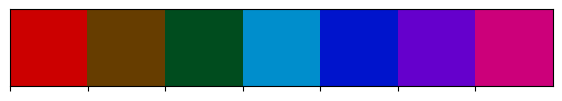

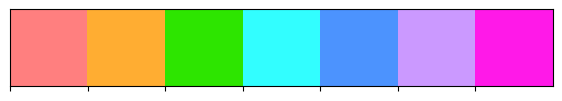

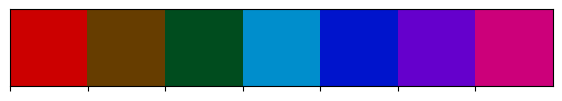

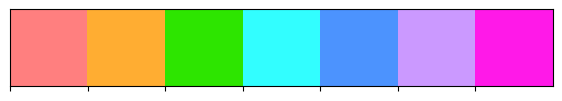

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os, sys

import pandas as pd
from math import pi

SCRIPT_DIR = os.path.dirname(os.path.abspath("..src"))
sys.path.append(os.path.dirname(SCRIPT_DIR))
from src.policy_analysis import discount_episode_reward, sum_ep_timesteps, set_blind_colors
light_colors, dark_colors = set_blind_colors()

In [2]:
dir = "../general_models/Plants/reward_model/"

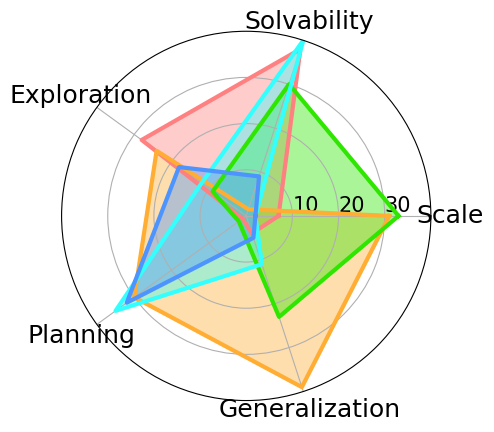

In [5]:
# Set data
df = pd.DataFrame({
'group': ['Env 1','Env 2','Env 3','Env 4', "Env 5"],
'Scale': [7, 31, 33, 2, 2],
'Solvability': [38, 1.5, 30, 40, 9],
'Exploration': [28, 24, 9, 12, 18],
'Planning': [1, 30, 2, 35, 32],
'Generalization': [4, 39, 23, 11, 5],
})
 
# number of variable
categories=list(df)[1:]
N = len(categories)
 
# We are going to plot the first line of the data frame.
# But we need to repeat the first value to close the circular graph:
plt.figure(figsize=(5, 5))
for i in range(5):
    color=  light_colors[i]
    values=df.loc[i].drop('group').values.flatten().tolist()
    values += values[:1]
    values
     
    # What will be the angle of each axis in the plot? (we divide the plot / number of variable)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
     
    # Initialise the spider plot
    ax = plt.subplot(111, polar=True)
     
    # Plot data
    ax.plot(angles, values, linewidth=3, c=color, label=df.loc[i].group)
     
    # Fill area
    ax.fill(angles, values, c=color, alpha=0.4)

# Show the graph
# Draw one axe per variable + add labels
plt.xticks(angles[:-1], categories, color='Black', size=18)
ax.set_rlabel_position(0)
plt.yticks([10,20,30], ["10","20","30"], color="Black", size=15)
plt.ylim(0, 40)
# plt.legend(fontsize=15)
plt.tight_layout()
# plt.savefig(dir + "/spider_plot_mon_mdp_benchmark.pdf", dpi=300)

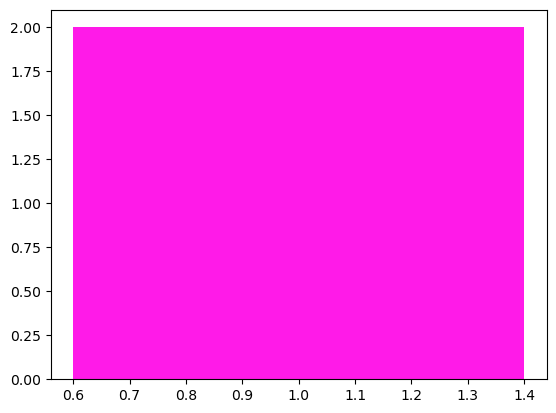

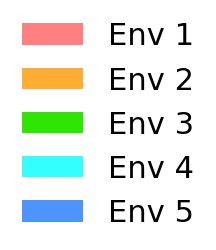

In [4]:
legends = ["Window size = 3", "Window size = 5", "Window size = 7", "Bird-view"]
f = lambda m,c: plt.bar(1,2, color=c)[0]
handles = [f("s", light_colors[i]) for i in range(7)]
fig = plt.figure(figsize=(2, 2.5))
fig.legend(handles, list(df["group"]), fontsize=22, ncol=1, loc='center', frameon=False)
fig.gca().set_axis_off()
plt.tight_layout()
# fig.savefig(dir + "legend_vertical.pdf", dpi=300,)

['Env 1', 'Env 2', 'Env 3', 'Env 4', 'Env 5']